## Eksperimen Machine Learning - E-Commerce Sales
**Nama:** Michael Sanjaya
**Dataset:** E-Commerce Sales Dataset
**Task:** Klasifikasi - Prediksi apakah transaksi akan menghasilkan revenue positif

## 1. Perkenalan Dataset
Dataset ini berisi data transaksi e-commerence yang mencangkup informasi : Produk, Quantity, Harga, dan negarapelanggan. Sumber:https://www.kaggle.com/datasets/carrie1/ecommerce-data



## 2. Import Library

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
print("Library Berhasil Di Import")


Library Berhasil Di Import


## 3. Memuat Dataset

In [2]:
df = pd.read_csv("data.csv", encoding="latin1", nrows=50000)
print(df.head())
df.info()
df.describe(include = "all")

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    500

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,50000,50000,49858,50000.000000,50000,50000.000000,32119.000000,50000
unique,2338,2879,2817,NaN,2063,NaN,NaN,24
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,12/6/2010 16:57,NaN,NaN,United Kingdom
freq,675,284,289,NaN,675,NaN,NaN,47022
mean,NaN,NaN,NaN,8.293320,NaN,6.418361,15431.221987,NaN
std,NaN,NaN,NaN,55.528494,NaN,166.504827,1753.358819,NaN
min,NaN,NaN,NaN,-9360.000000,NaN,0.000000,12347.000000,NaN
25%,NaN,NaN,NaN,1.000000,NaN,1.250000,14057.000000,NaN
50%,NaN,NaN,NaN,2.000000,NaN,2.510000,15464.000000,NaN
75%,NaN,NaN,NaN,8.000000,NaN,4.250000,17059.000000,NaN


In [3]:
# Check Missing Value
print("Missing Values")
print(df.isnull().sum())

# Check Duplicated Data 
print("Duplicate Data")
print(f"Jumlah Baris Yang duplikat : {(df.duplicated().sum())}")

# Check Shape
print("Ukuran Data")
print(f"Baris : {df.shape[0]}, Kolom : {df.shape[1]}")

Missing Values
InvoiceNo          0
StockCode          0
Description      142
Quantity           0
InvoiceDate        0
UnitPrice          0
CustomerID     17881
Country            0
dtype: int64
Duplicate Data
Jumlah Baris Yang duplikat : 537
Ukuran Data
Baris : 50000, Kolom : 8


### Insight: Missing Values
- `CustomerID` memiliki **17.881 missing values (35.7%)** → baris ini akan di-drop
karena transaksi tanpa identitas customer tidak berguna untuk analisis
- `Description` memiliki **142 missing values (0.28%)** → jumlah kecil, aman di-drop
### Insight: Data Duplikat
- Ditemukan **537 baris duplikat** → akan dihapus untuk menghindari bias pada model

# 4. EDA Visuaisasi Raw Data

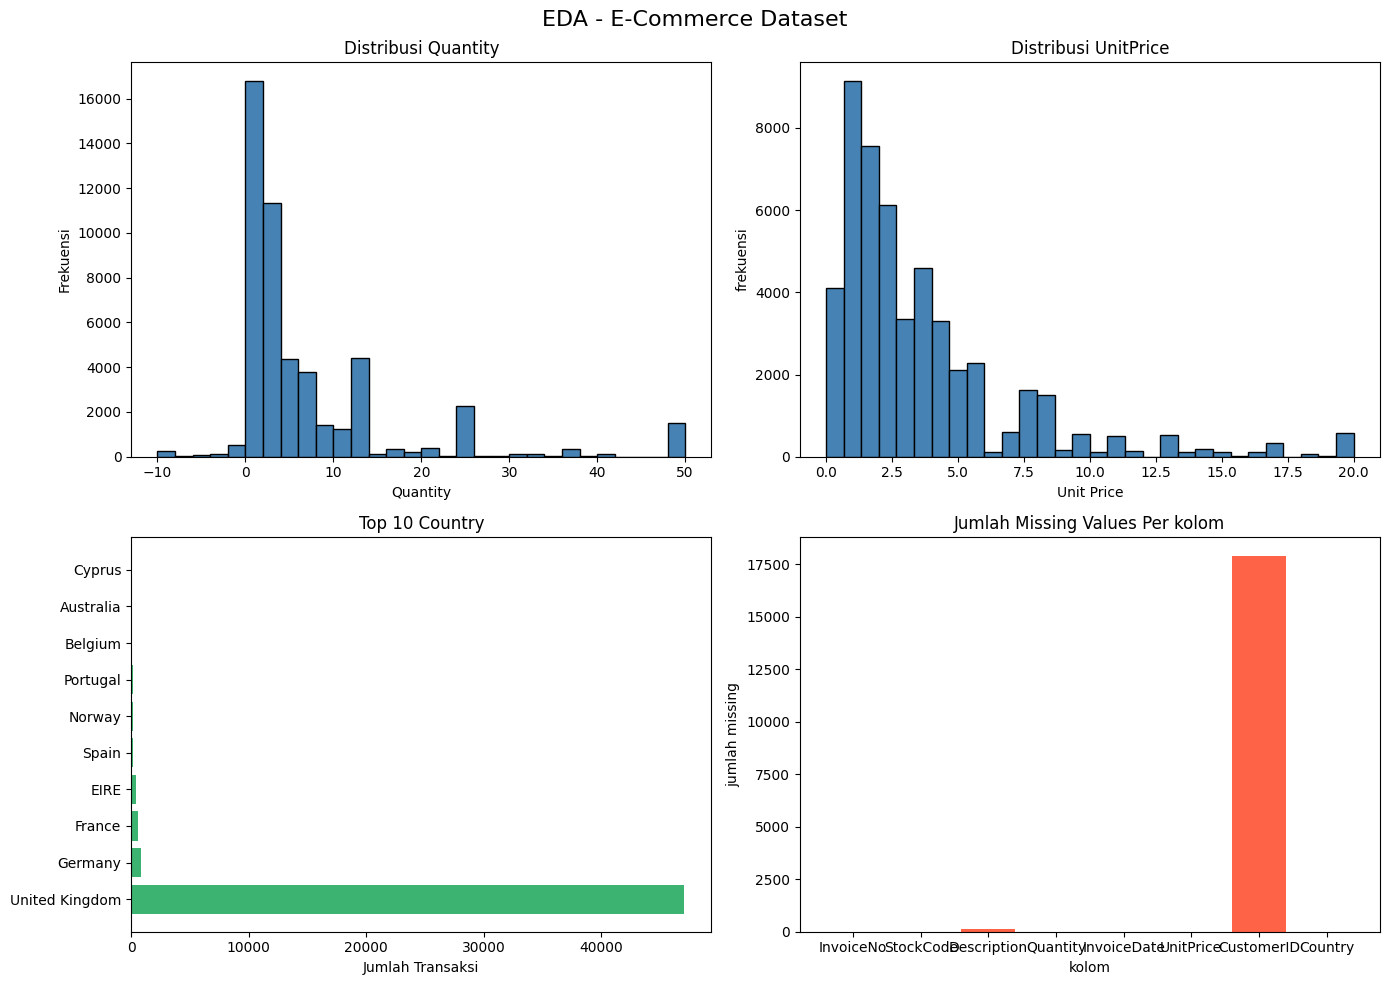

Visualisasi Berhasil & Disimpan


In [13]:
# EDA Visualisasi Raw Data

fig, axes = plt.subplots(2, 2, figsize = (14, 10))
fig.suptitle("EDA - E-Commerce Dataset", fontsize = 16)

# 1. Distrubusi Quantity
# Untuk melihat sebaran jumlah pembelian dan deteksi outlier/nilai negatif
axes[0,0].hist(df['Quantity'].clip(-10, 50), bins = 30, color = 'steelblue', edgecolor= 'black')
axes[0,0].set_title('Distribusi Quantity')
axes[0,0].set_xlabel('Quantity')
axes[0,0].set_ylabel('Frekuensi')

# 2. Distribusi UnitPrice
# Untuk melihat range harga produk dan detesi harga 0 atau ekstreme
axes[0,1].hist(df['UnitPrice'].clip(0, 20), bins = 30, color = 'steelblue', edgecolor = 'black')
axes[0,1].set_title('Distribusi UnitPrice')
axes[0,1].set_xlabel("Unit Price")
axes[0,1].set_ylabel("frekuensi")

# Top 10 Negara Dengan Jumlah pembelian terbanyak
# Untuk melihat pasar terebesar di negara mana
top_countries = df['Country'].value_counts().head(10)
axes[1,0].barh(top_countries.index, top_countries.values, color = 'mediumseagreen')
axes[1,0].set_title('Top 10 Country')
axes[1,0].set_xlabel('Jumlah Transaksi')

# Missing Values Visualisasi 
# Untuk melihat secara visual bagian kolom yang banyak kosongnya
missing = df.isnull().sum()
missing - missing[missing>0]
axes[1,1].bar(missing.index, missing.values, color= 'tomato')
axes[1,1].set_title('Jumlah Missing Values Per kolom')
axes[1,1].set_xlabel('kolom')
axes[1,1].set_ylabel('jumlah missing')

plt.tight_layout()
plt.savefig('EDA_RawData_Visualization.png')
plt.show()
print("Visualisasi Berhasil & Disimpan")

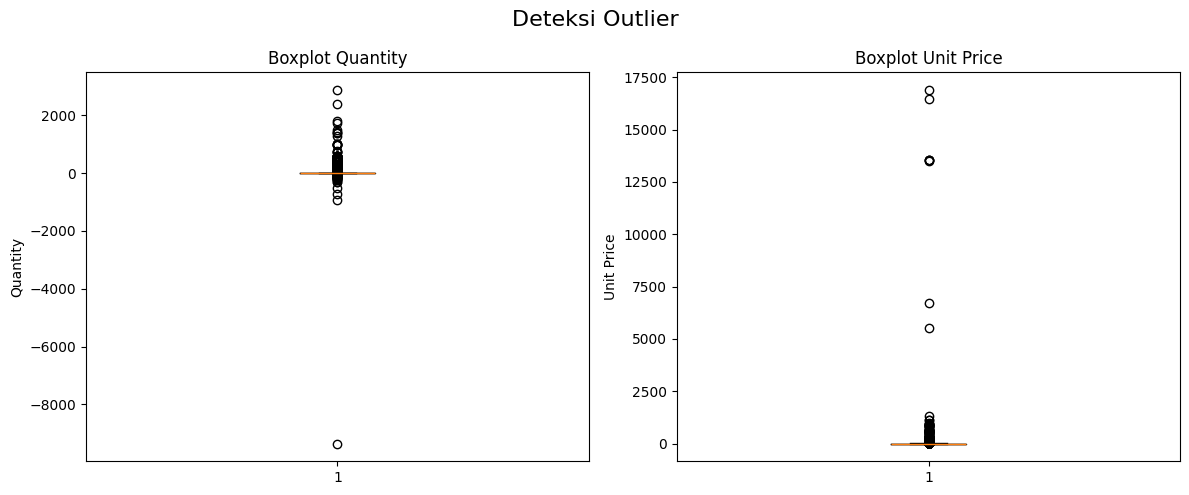

Visualisasi Boxplt Selesai & Gambar Disimpan


In [14]:
# Visualisasi Boxplt untuk deteksi outlier lebih lanjut
fig, axes = plt.subplots(1, 2, figsize=(12,5))
fig.suptitle('Deteksi Outlier', fontsize = 16)

# Boxplot Quantity
# Kotak = 50% data normal, titik diluar = outlier
axes[0].boxplot(df['Quantity'], vert = True)
axes[0].set_title('Boxplot Quantity')
axes[0].set_ylabel('Quantity')

# Boxplot Unit Price
axes[1].boxplot(df['UnitPrice'], vert = True)
axes[1].set_title('Boxplot Unit Price')
axes[1].set_ylabel('Unit Price')

plt.tight_layout()
plt.savefig('RawOutlier_Visualization.png')
plt.show()
print("Visualisasi Boxplt Selesai & Gambar Disimpan")

### Kesimpulan EDA
- 90% transaksi berasal dari United Kingdom
- Mayoritas produk berharga £1-5
- Ditemukan 537 duplikat dan 17.881 transaksi tanpa CustomerID
- Revenue rata-rata per transaksi: £X

## 5. Data Preprocessing

In [6]:
# Menyalin Dataframe asli
df_clean = df.copy()
print(f"Data Awal : {df_clean.shape}")

Data Awal : (50000, 8)


In [7]:
# Drop Baris pada kolom Quantity negatif (transaksi retur/cancelled)
df_clean = df_clean[df_clean['Quantity'] > 0 ]
print(f"Quantity Negatif Setelah Drop : {df_clean.shape}")

# Drop baris dengan unit price = 0 atau ekstreme lebih ( > 500)
df_clean = df_clean[(df_clean['UnitPrice']> 0) & (df_clean['UnitPrice'] < 500)]
print(f"Unit Price Setelah Drop : {df_clean.shape}")

# Drop baris missing dari kolom CostumerID 
df_clean = df_clean.dropna(subset=['CustomerID'])
print(f"Baris CostumerID Setelah Drop : {df_clean.shape}")

# Drop Baris Missing dari kolom Description
df_clean = df_clean.dropna(subset=['Description'])
print(f"Description Setelah Drop : {df_clean.shape}")

# Drop Data Duplikat
df_clean = df_clean.drop_duplicates()
print(f"Setelah Drop Duplikat : {df_clean.shape}")
print("Drop Selesai")

Quantity Negatif Setelah Drop : (48992, 8)
Unit Price Setelah Drop : (48750, 8)
Baris CostumerID Setelah Drop : (31234, 8)
Description Setelah Drop : (31234, 8)
Setelah Drop Duplikat : (30711, 8)
Drop Selesai


In [8]:
# Fitur processing
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['UnitPrice']
print("Contoh Revenue : ")
print(df_clean[['Quantity','UnitPrice','Revenue']].head())

Contoh Revenue : 
   Quantity  UnitPrice  Revenue
0         6       2.55    15.30
1         6       3.39    20.34
2         8       2.75    22.00
3         6       3.39    20.34
4         6       3.39    20.34


In [9]:
# Mengubah teks menjadi angka menggunakan Label Encoder
le = LabelEncoder()

# Encoding Kolom Country
df_clean['Country_encoded'] = le.fit_transform(df_clean['Country'])
print("Contoh Hasil Encoding Country")
print(df_clean[['Country', 'Country_encoded']].head())

Contoh Hasil Encoding Country
          Country  Country_encoded
0  United Kingdom               21
1  United Kingdom               21
2  United Kingdom               21
3  United Kingdom               21
4  United Kingdom               21


In [10]:
# Normalisasi Fitur 
# Tujuan : Menyamakan skala semua anga ( 0 sampai 1 / mean 0)
# Alasan : karena Quantity (1-2880) sedangkan UnitPrice (0-500)
scaler = StandardScaler()
num_cols = ['Quantity', 'UnitPrice', 'Revenue']
df_clean[num_cols] = scaler.fit_transform(df_clean[num_cols])

print("Data Setelah Normalisasi :")
print(df_clean[num_cols].describe().round(2))

Data Setelah Normalisasi :
       Quantity  UnitPrice   Revenue
count  30711.00   30711.00  30711.00
mean      -0.00      -0.00     -0.00
std        1.00       1.00      1.00
min       -0.26      -0.61     -0.30
25%       -0.23      -0.37     -0.24
50%       -0.19      -0.21     -0.15
75%       -0.01       0.12     -0.03
max       64.60      58.31     51.42


In [11]:
# Menyimpan Data Hasil Preprocessing
df_clean.to_csv('ecommerce_preprocessing.csv', index = False)

print(f"Dataset Preprocessing disimpan!")
print(f"Shape Final : {df_clean.shape}")
print(f"\n Kolom Final:")
print(df_clean.columns.tolist())

Dataset Preprocessing disimpan!
Shape Final : (30711, 10)

 Kolom Final:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'Revenue', 'Country_encoded']


### Kesimpulan Preprocessing
- Data awal: **50.000 baris**
- Data setelah cleaning: **30.711 baris**
- Fitur baru ditambahkan: **Revenue** (Quantity × UnitPrice)
- Data siap digunakan untuk pelatihan model ML 

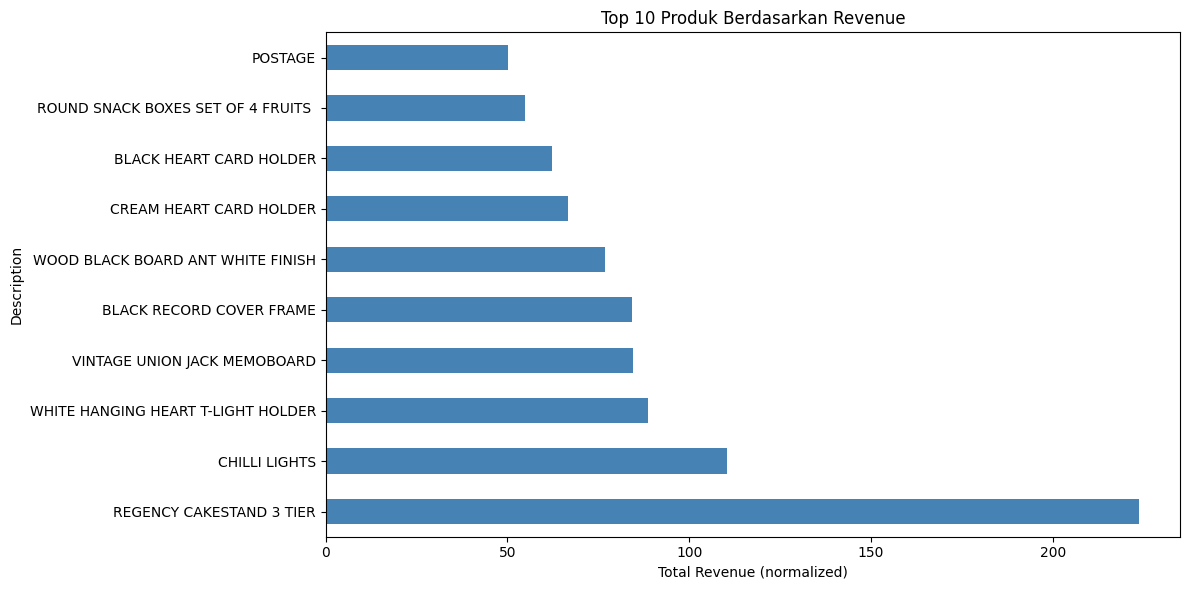

In [17]:
# Visualsisasi Top 10 Produk Berdasarkan Revenue
top_products = df_clean.groupby('Description')['Revenue'].sum().sort_values(ascending = False).head(10)

plt.figure(figsize=(12,6))
top_products.plot(kind='barh', color='steelblue')
plt.title('Top 10 Produk Berdasarkan Revenue')
plt.xlabel('Total Revenue (normalized)')
plt.tight_layout()
plt.savefig('top_products.png')
plt.show()

### Insight: Top Produk
- **REGENCY CAKESTAND 3 TIER** memiliki total revenue tertinggi (normalized ~225)
- Produk dengan revenue tinggi tidak selalu terjual paling sering — harga satuan
tinggi berkontribusi besar pada revenue
- Rekomendasi bisnis: fokus stok dan promosi pada top 3 produk ini